In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('iris_sujo.csv')

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  147 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  147 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [2]:
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,NaN,0.2,Iris-setosa


In [3]:
data.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [4]:
data.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

In [5]:
data.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object

In [6]:
data.isna().sum()

Id               0
SepalLengthCm    3
SepalWidthCm     0
PetalLengthCm    3
PetalWidthCm     0
Species          0
dtype: int64

In [7]:
data[data["SepalLengthCm"].isna()] 

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
8,9,NaN,2.9,1.4,0.2,Iris-setosa
30,31,NaN,3.1,1.6,0.2,Iris-setosa
131,132,NaN,3.8,6.4,2.0,Iris-virginica


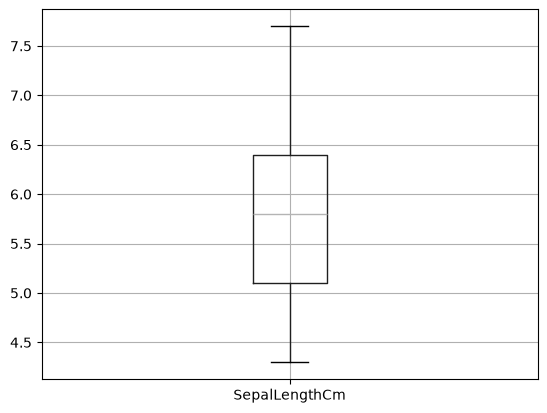

In [8]:
data.boxplot(column="SepalLengthCm")
plt.show()

In [9]:
data["SepalLengthCm"].describe()

count    147.000000
mean       5.846259
std        0.805654
min        4.300000
25%        5.100000
50%        5.800000
75%        6.400000
max        7.700000
Name: SepalLengthCm, dtype: float64

In [10]:
#Para especificar o tipo de íris, já que as sépalas por espécie são diferentes
data.groupby("Species")["SepalLengthCm"].describe()

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Iris-setosa,48.0,5.022917,0.347171,4.3,4.8,5.0,5.2,5.8
Iris-versicolor,50.0,5.936000,0.516171,4.9,5.6,5.9,6.3,7.0
Iris-virginica,49.0,6.561224,0.613330,4.9,6.2,6.5,6.9,7.7


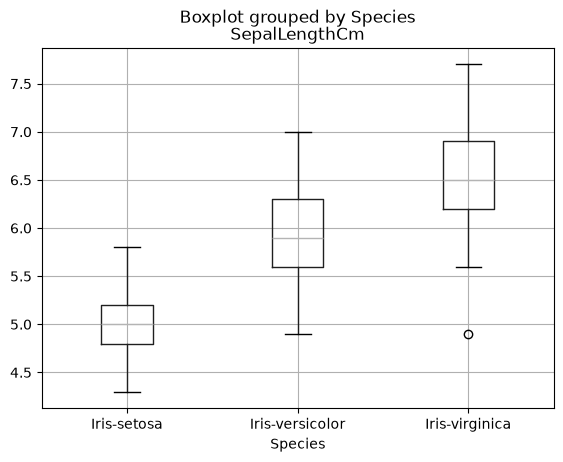

In [11]:
data.boxplot(column="SepalLengthCm",by="Species")

plt.show()

In [ ]:
# def sepal_transform(valor):
#     if pd.isna(valor):
#         return 5.8
#     return valor  

# data["SepalLengthCm"] = data["SepalLengthCm"].apply(sepal_transform)

medias = data.groupby("Species")["SepalLengthCm"].transform("mean")

data["SepalLengthCm"] = data["SepalLengthCm"].fillna(medias)

data.loc[data["Id"].isin([9, 31, 132]),["Id", "Species", "SepalLengthCm"]]

,Id,Species,SepalLengthCm
8,9,Iris-setosa,5.022917
30,31,Iris-setosa,5.022917
131,132,Iris-virginica,6.561224


In [16]:
data.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    3
PetalWidthCm     0
Species          0
dtype: int64

In [18]:
data[data["PetalLengthCm"].isna()] 

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
4,5,5.0,3.6,NaN,0.2,Iris-setosa
81,82,5.5,2.4,NaN,1.0,Iris-versicolor
129,130,7.2,3.0,NaN,1.6,Iris-virginica


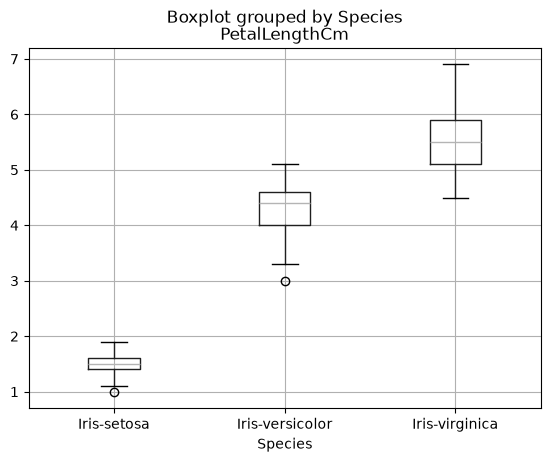

In [19]:
data.boxplot(column="PetalLengthCm",by="Species")
plt.show()

In [23]:
data.groupby("Species")["PetalLengthCm"].describe()

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Iris-setosa,50.0,1.465306,0.173265,1.0,1.4,1.500000,1.575,1.9
Iris-versicolor,50.0,4.271429,0.462910,3.0,4.0,4.350000,4.600,5.1
Iris-virginica,50.0,5.546939,0.550733,4.5,5.1,5.523469,5.875,6.9


In [22]:
mediasPetal = data.groupby("Species")["PetalLengthCm"].transform("mean")

data["PetalLengthCm"] = data["PetalLengthCm"].fillna(mediasPetal)

data.loc[data["Id"].isin([5, 82, 130]),["Id", "Species", "PetalLengthCm"]]

,Id,Species,PetalLengthCm
4,5,Iris-setosa,1.465306
81,82,Iris-versicolor,4.271429
129,130,Iris-virginica,5.546939


In [25]:
data.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [28]:
data["SepalWidthCm"].describe()
data.groupby("Species")["SepalWidthCm"].describe()

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Iris-setosa,50.0,3.418,0.381024,2.3,3.125,3.4,3.675,4.4
Iris-versicolor,50.0,2.770,0.313798,2.0,2.525,2.8,3.000,3.4
Iris-virginica,50.0,2.974,0.322497,2.2,2.800,3.0,3.175,3.8


In [31]:
data["PetalWidthCm"].describe()
data.groupby("Species")["PetalWidthCm"].describe()


,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Iris-setosa,50.0,0.244,0.107210,0.1,0.2,0.2,0.3,0.6
Iris-versicolor,50.0,1.326,0.197753,1.0,1.2,1.3,1.5,1.8
Iris-virginica,50.0,2.026,0.274650,1.4,1.8,2.0,2.3,2.5


In [33]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [34]:
data.to_csv("./dados_limpos.csv", index=False)